# HW3
جداسازی متن از پس‌زمینه در تصاویر اسکن‌شده 

In [1]:
import os
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter, rank_filter

%matplotlib inline

IN_DIR = 'Input_Image'
OUT_DIR = 'Output_Image'
for p in ['Part_1','Part_2','Part_3','Part_4']:
    os.makedirs(OUT_DIR+'/'+p, exist_ok=True)

os.listdir(IN_DIR)

['ScannedText.jpg']

In [2]:
img = cv2.imread(IN_DIR+'/ScannedText.jpg')
img.shape

(1365, 1024, 3)

uint8 2 233 (1365, 1024)


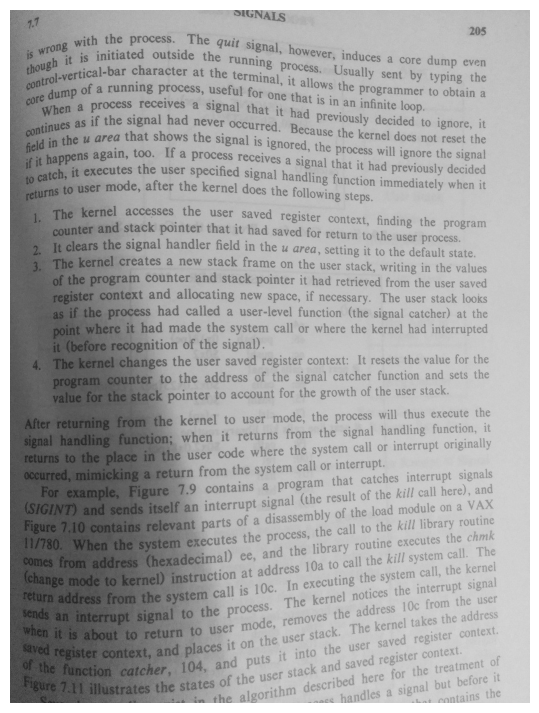

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.uint8)
print(gray.dtype, gray.min(), gray.max(), gray.shape)

plt.figure(figsize=(7,9))
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()


<div dir="rtl" style="text-align: right;">
 قسمت ۱ - آستانه‌گذاری ساده
</div>

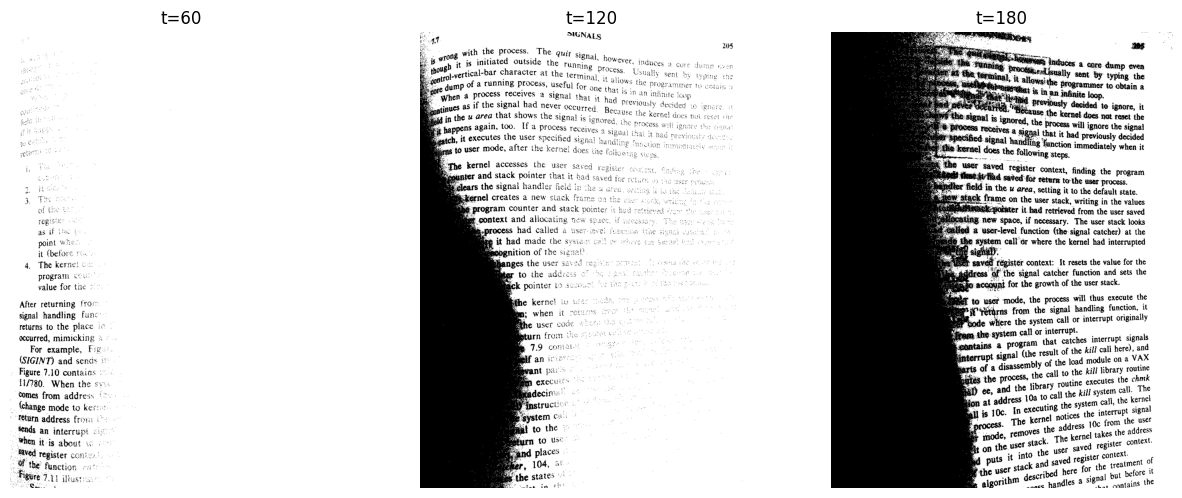

In [4]:
def simple_thresh(im, t):
    out = np.where(im >= t, 255, 0).astype(np.uint8)
    return out

for t in [60, 120, 180]:
    b = simple_thresh(gray, t)
    cv2.imwrite(OUT_DIR+'/Part_1/thresh_'+str(t)+'.png', b)

plt.figure(figsize=(15,6))
for i,t in enumerate([60,120,180]):
    b = simple_thresh(gray, t)
    plt.subplot(1,3,i+1)
    plt.imshow(b, cmap='gray')
    plt.title('t='+str(t))
    plt.axis('off')
plt.show()

<div dir="rtl" style="text-align: right;">
 قسمت ۲ - Dilation حوزه پیوسته (maximum filter)
</div>

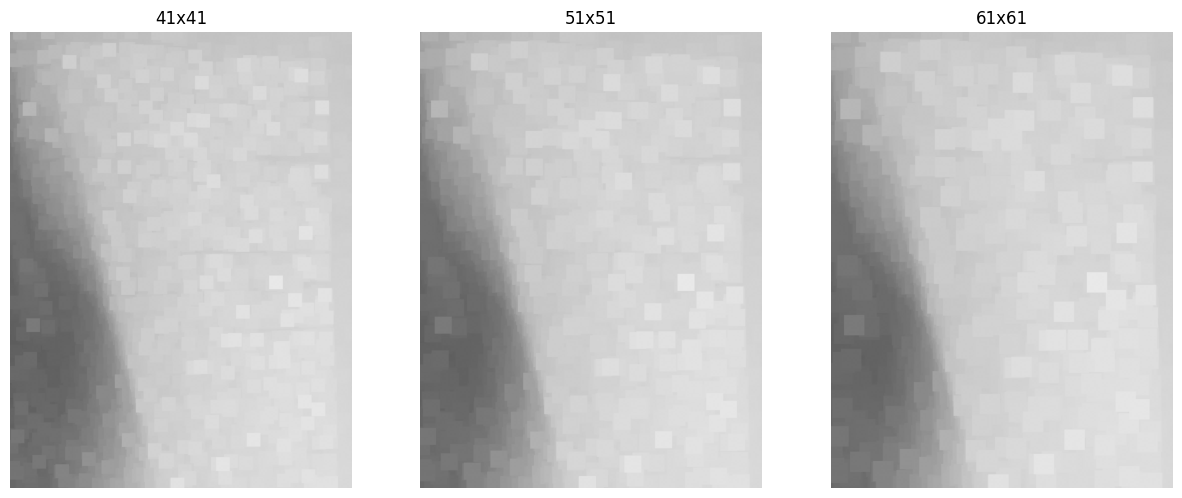

In [ ]:
dil = {}
for w in [41,51,61]:
    d = maximum_filter(gray.astype(np.float64), size=w, mode='constant', cval=0)
    dil[w] = d
    cv2.imwrite(OUT_DIR+'/Part_2/dilation_'+str(w)+'.png', np.clip(d,0,255).astype(np.uint8))

plt.figure(figsize=(15,6))
for i,w in enumerate([41,51,61]):
    plt.subplot(1,3,i+1)
    plt.imshow(dil[w], cmap='gray', vmin=0, vmax=255)
    plt.title(str(w)+'x'+str(w))
    plt.axis('off')
plt.show()


<div dir="rtl" style="text-align: right;">
قسمت ۳ - کم کردن تصویر اصلی از پس‌زمینه تخمینی
</div>

In [6]:
diff2 = {}
for w in [41,51,61]:
    d = dil[w] - gray.astype(np.float64)
    print(w, 'min', d.min(), 'max', d.max())   # چک میکنم منفی نداشته باشه
    diff2[w] = np.clip(d,0,255).astype(np.uint8)
    cv2.imwrite(OUT_DIR+'/Part_3/diff_'+str(w)+'.png', diff2[w])

41 min 0.0 max 154.0
51 min 0.0 max 154.0
61 min 0.0 max 154.0


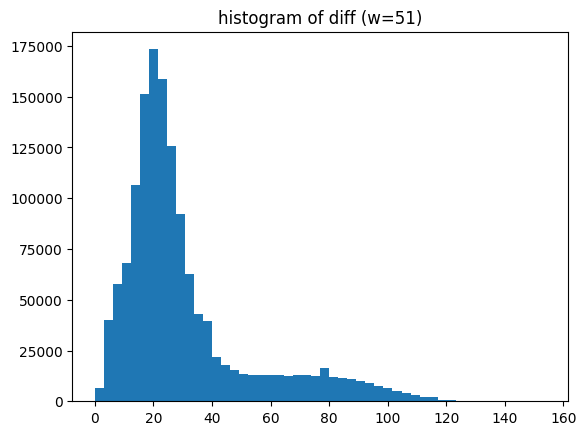

In [ ]:
plt.hist(diff2[51].ravel(), bins=50)
plt.title('histogram of diff (w=51)')
plt.show()

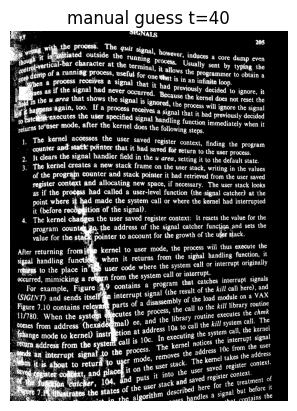

In [ ]:
test_t = 40
b_test = np.where(diff2[51] >= test_t, 255, 0).astype(np.uint8)
plt.imshow(b_test, cmap='gray')
plt.title('manual guess t='+str(test_t))
plt.axis('off')
plt.show()

41 otsu threshold = 47.0
51 otsu threshold = 48.0
61 otsu threshold = 50.0


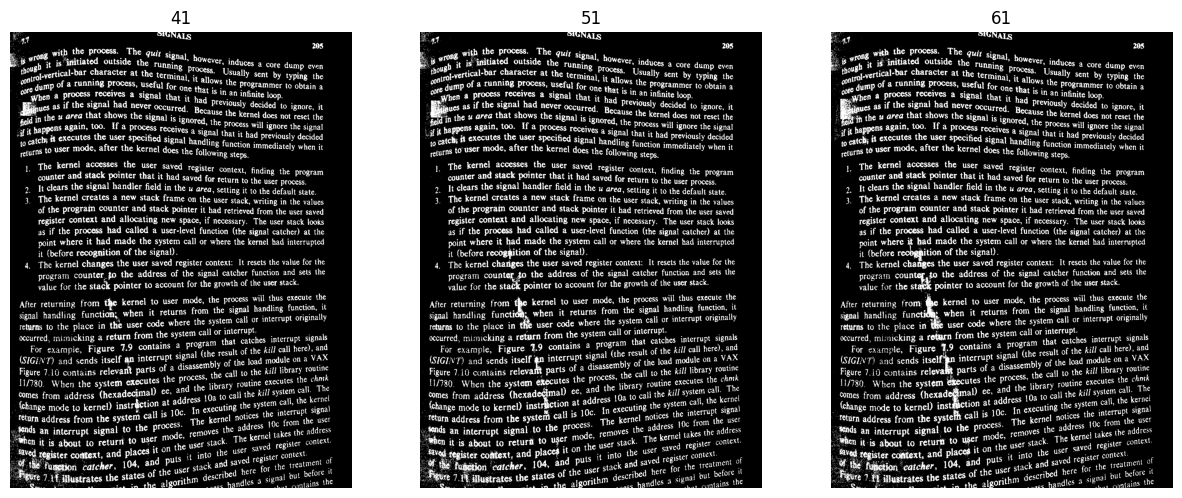

In [9]:
bin3 = {}
for w in [41,51,61]:
    t, b = cv2.threshold(diff2[w], 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    print(w, 'otsu threshold =', t)
    bin3[w] = b
    cv2.imwrite(OUT_DIR+'/Part_3/thresh_'+str(w)+'.png', b)

plt.figure(figsize=(15,6))
for i,w in enumerate([41,51,61]):
    plt.subplot(1,3,i+1)
    plt.imshow(bin3[w], cmap='gray')
    plt.title(str(w))
    plt.axis('off')
plt.show()


<div dir="rtl" style="text-align: right;">
قسمت ۴ ـ Rank Filter
</div>

In [ ]:
t0 = time.time()
rk = rank_filter(gray.astype(np.float64), rank=-7, size=51, mode='constant', cval=0)
t_rank = time.time()-t0
print('rank filter time:', t_rank)

t0 = time.time()
mx = maximum_filter(gray.astype(np.float64), size=51, mode='constant', cval=0)
t_dil = time.time()-t0
print('dilation(max) time:', t_dil)

print('rank is', t_rank/t_dil, 'x slower')

rank filter time: 22.953235149383545
dilation(max) time: 0.05535578727722168
rank is 414.6492404567166 x slower


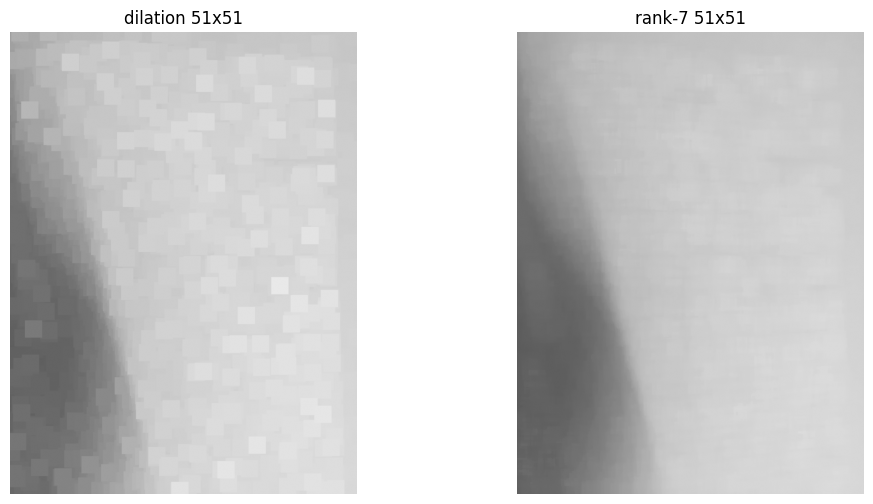

In [11]:
cv2.imwrite(OUT_DIR+'/Part_4/rank7_51.png', np.clip(rk,0,255).astype(np.uint8))

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(mx, cmap='gray', vmin=0, vmax=255); plt.title('dilation 51x51'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(rk, cmap='gray', vmin=0, vmax=255); plt.title('rank-7 51x51'); plt.axis('off')
plt.show()

min -28.0 max 147.0
otsu threshold for rank-diff: 42.0


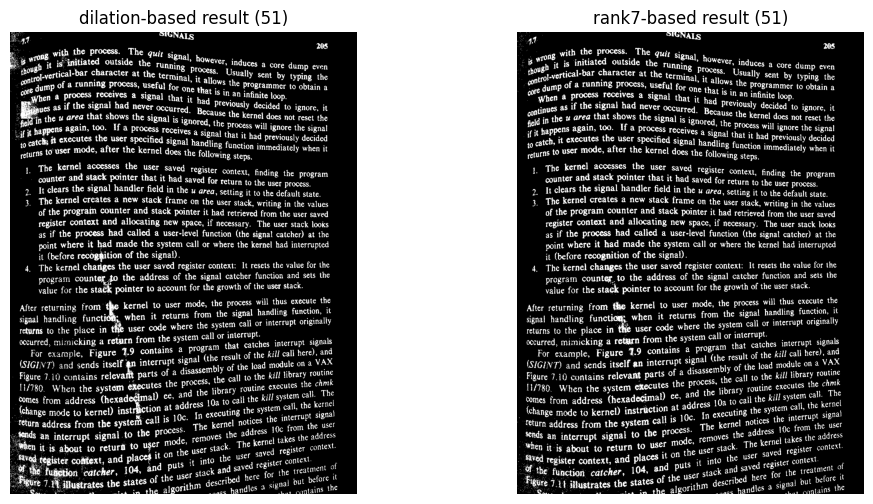

In [12]:
diff4 = rk - gray.astype(np.float64)
print('min', diff4.min(), 'max', diff4.max())
diff4_u8 = np.clip(diff4,0,255).astype(np.uint8)
cv2.imwrite(OUT_DIR+'/Part_4/diff_rank7_51.png', diff4_u8)

t4, bin4 = cv2.threshold(diff4_u8, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print('otsu threshold for rank-diff:', t4)
cv2.imwrite(OUT_DIR+'/Part_4/thresh_rank7_51.png', bin4)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(bin3[51], cmap='gray'); plt.title('dilation-based result (51)'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(bin4, cmap='gray'); plt.title('rank7-based result (51)'); plt.axis('off')
plt.show()